# Topological Data Analysis Workshop
## Introduction to Persistent Homology

**Workshop on Topological Machine Learning**

This notebook covers the fundamentals of persistent homology:
1. Filtrations
2. Data to Space
3. Approximating Manifolds using Offsets
4. Simplicial Homology
5. Persistent Homology
6. Persistence Barcodes and Diagrams
7. Bottleneck Distance

---

In [ ]:
!pip install giotto-tda gudhi

In [ ]:
# Required imports
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# Giotto-TDA plotting utilities
from gtda.plotting import plot_diagram, plot_point_cloud

# Ripser for persistent homology
from gph import ripser_parallel
from gtda.homology._utils import _postprocess_diagrams

# GUDHI for bottleneck distance
import gudhi

# For toy datasets
from sklearn import datasets

# Interactive widgets
from ipywidgets import interact, FloatSlider, IntSlider

print("All imports successful!")

All imports successful!



# 1. Simplicial Homology (Background)

## Simplicial Complexes

### Definition (Affine Independence)

Points $v_0, \ldots, v_k \in \mathbb{R}^N$ are **affinely independent** if:

$$\sum_{i=0}^k t_i v_i = 0 \text{ and } \sum_{i=0}^k t_i = 0 \Rightarrow t_0 = t_1 = \cdots = t_k = 0$$

### Definition (k-Simplex)

A **k-simplex** $\sigma$ is the convex hull of $k+1$ affinely independent points $\{v_0, \ldots, v_k\}$.

Denoted: $\sigma = [v_0, \ldots, v_k]$

### Building Blocks:
- **0-simplex:** single point (vertex)
- **1-simplex:** line segment (edge)
- **2-simplex:** filled triangle
- **3-simplex:** filled tetrahedron

### Definition (Simplicial Complex K)

A simplicial complex is a (finite) union of simplices such that:
1. For all $\sigma \in K$, all faces of $\sigma$ are also in $K$
2. The intersection of any two simplices is either empty or a common face

---
# 2. Filtrations

## What is a Filtration?

In topology, we usually study a *single* space: a simplicial complex, a graph, a surface, etc.

But real data does not come with a single obvious space. A **filtration** is a way to watch a space grow as we change a scale parameter.

### Definition

Let $K$ be a simplicial complex on a vertex set $S$. A **filtration** is a nested sequence:

$$K_0 \subset K_1 \subset \cdots \subset K_n = K$$

of subcomplexes (i.e., each $K_i$ is a subcomplex).

That is: **as the parameter increases, we only add simplices — never remove them.**

### Why do we need filtrations?

Topology by itself is too rigid. It asks questions like: "How many connected components does this space have?"

But for data, the answer depends on scale:
- At a very small scale: everything is disconnected
- At a very large scale: everything merges into one blob

Instead of a single rigid answer, filtrations show *how topology changes across scales*.

**Persistent homology tracks which features survive as the filtration evolves.**

### Key points about filtrations:
1. The first step is to convert data into a shape
2. Examine data at different resolutions by adjusting a scale parameter
4. The choice of this scale parameter can greatly influence the performance

---
# 3. Data to Space

## Point Clouds

The most common type of data is a **point cloud** — a set of vectors:

$$X = \{x_1, \ldots, x_N\} \subset \mathbb{R}^d$$

A point cloud is a **0-dimensional simplicial complex** — it has no interesting topology by itself!

### The Key Question

Is there a nice topological space (say a manifold) $M$ such that $X \subset M$?

**Goal:** Recover the topology of the underlying space from the point cloud sample.

Let's generate some toy datasets to work with:

In [ ]:
# Generate toy datasets

# 1. Noisy circle (should have one connected component and one loop)
circle_data = datasets.make_circles(n_samples=100, noise=0.05, factor=0.5, random_state=42)[0]
# Take only the outer circle
circle_data = circle_data[circle_data[:, 0]**2 + circle_data[:, 1]**2 > 0.3]

# 2. Two concentric circles
two_circles = datasets.make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)[0]

# 3. Simple points for visualization
simple_points = datasets.make_circles(n_samples=12, noise=0.08, factor=0.6, random_state=42)[0]

print(f"Circle dataset: {circle_data.shape[0]} points")
print(f"Two circles dataset: {two_circles.shape[0]} points")
print(f"Simple points: {simple_points.shape[0]} points")

Circle dataset: 60 points
Two circles dataset: 200 points
Simple points: 12 points


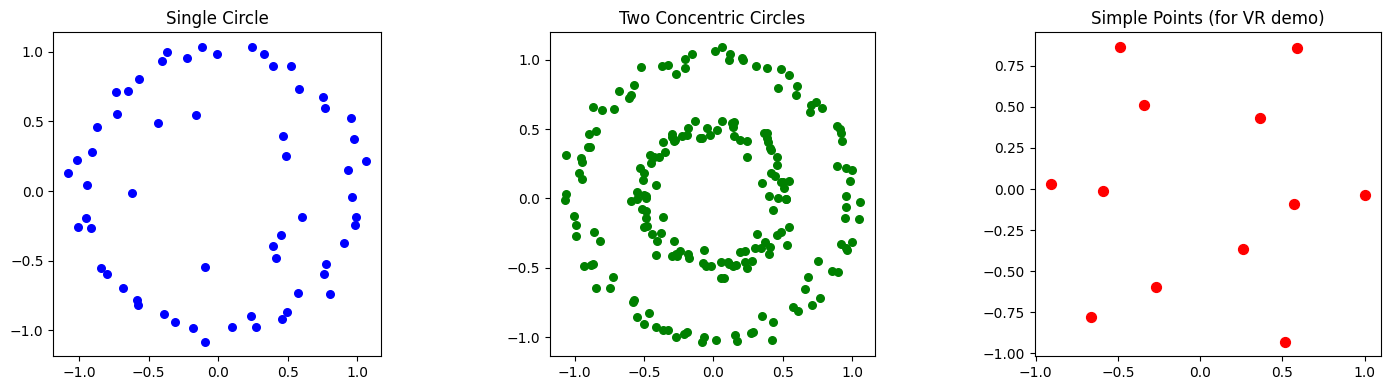

In [ ]:
# Visualize the datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(circle_data[:, 0], circle_data[:, 1], s=30, c='blue')
axes[0].set_title('Single Circle')
axes[0].set_aspect('equal')

axes[1].scatter(two_circles[:, 0], two_circles[:, 1], s=30, c='green')
axes[1].set_title('Two Concentric Circles')
axes[1].set_aspect('equal')

axes[2].scatter(simple_points[:, 0], simple_points[:, 1], s=50, c='red')
axes[2].set_title('Simple Points (for VR demo)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

---
# 4. Approximating Manifolds using Offsets

## 4.1 Offset

Given a compact set $Y \subset \mathbb{R}^d$ and a real number $\varepsilon > 0$, the **$\varepsilon$-offset** of $Y$ is:

$$Y_\varepsilon := \bigcup_{y \in Y} B(y; \varepsilon)$$

where $B(y; \varepsilon)$ is the ball of radius $\varepsilon$ centered at point $y$.

Intuition: We build balls around a point, their size depending on the value of ε.

In [ ]:
# Interactive visualization of offset growing

def plot_offset(epsilon):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the balls (offset)
    for point in simple_points:
        circle = plt.Circle(point, epsilon, color='lightblue', alpha=0.3)
        ax.add_patch(circle)

    # Plot the points
    ax.scatter(simple_points[:, 0], simple_points[:, 1], s=50, c='blue', zorder=5)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.set_title(f'$\\varepsilon$-Offset with $\\varepsilon$ = {epsilon:.2f}')
    ax.grid(True, alpha=0.3)
    plt.show()
    # plt.close(fig)
    # return None

interact(
    plot_offset,
    epsilon=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.1, description='ε')

);

interactive(children=(FloatSlider(value=0.1, description='ε', max=2.0, step=0.05), Output()), _dom_classes=('w…

You can use the slider to visualise how the offsets grow and merge.

## 4.2 Reconstruction Theorems

### Theorem (Chazal and Lieutier 2007)

Let $X$ be a PCD and $M$ be a closed manifold in $\mathbb{R}^d$ and let $r > 0$ be such that $d_H(X, M) < r$. Further assume that the reach of both sets is at least $2r$.

Then there is an $\varepsilon$ with $0 < \varepsilon < 2r$ such that $X_\varepsilon$ and $M_\varepsilon$ are **homotopy equivalent**.

### Theorem (Niyogi et al. 2008)

The Betti numbers of Riemannian manifolds with positive reach can be recovered with high probability from offsets of a sample on (or close to) the manifold.

**Key Insight:** We can approximate the topology of a manifold from a point cloud sample.

## 3.5 Cech Complex

### Definition: Cech Complex

Given a PCD $X$ and $r > 0$, the **Cech complex** $C_r(X)$ is an (abstract) simplicial complex whose simplices are those subsets $\sigma \subset X$ such that:

$$\bigcap_{x \in \sigma} B(x; r) \neq \emptyset$$

**In words:** A subset forms a simplex if all the balls around those points have a common intersection.

### Theorem: Nerve Lemma

The offset $X_r$ of a PCD $X$ is **homotopy equivalent** to the Cech complex $C_r(X)$.

**This is crucial:** Instead of working with the continuous offset, we can work with the combinatorial Cech complex!

## 4.3 Vietoris-Rips Complex

### Definition

Let $X \subset \mathbb{R}^N$ be a finite point cloud and $\varepsilon > 0$. The **Vietoris-Rips complex** $VR_\varepsilon(X)$ has as $k$-simplices those $(k+1)$-subsets $\{x_{i_0}, \ldots, x_{i_k}\}$ of $X$ for which:

$$d(x_{i_j}, x_{i_l}) \leq \varepsilon \quad \text{for all } j, l$$

**In words:** A subset forms a simplex if ALL pairwise distances are at most $\varepsilon$.

### Key Properties:
1. In general $VR_\varepsilon(X)$ does not embed in $\mathbb{R}^N$
2. If $\varepsilon < \varepsilon'$ then $VR_\varepsilon(X) \subseteq VR_{\varepsilon'}(X)$ (this gives us a filtration!)
3. It is a **clique complex** — completely determined by its 1-skeleton

### Relationship between Cech and Vietoris-Rips

$$C_r(X) \subseteq VR_{2r}(X) \subseteq C_{2r}(X)$$

The VR complex is easier to compute since we only need pairwise distances.

In [ ]:
def plot_vr_complex_interactive(data, title):
    """Create interactive VR complex visualization for any dataset."""
    distance_matrix = squareform(pdist(data))

    def plot_vr(epsilon):
        fig, ax = plt.subplots(figsize=(8, 8))

        # Draw triangles (2-simplices)
        for i, j, k in combinations(range(len(data)), 3):
            if (distance_matrix[i, j] <= epsilon and
                distance_matrix[j, k] <= epsilon and
                distance_matrix[i, k] <= epsilon):
                triangle = plt.Polygon(
                    [data[i], data[j], data[k]],
                    color='orange', alpha=0.3
                )
                ax.add_patch(triangle)

        # Draw edges (1-simplices)
        for i, j in combinations(range(len(data)), 2):
            if distance_matrix[i, j] <= epsilon:
                ax.plot([data[i, 0], data[j, 0]],
                       [data[i, 1], data[j, 1]], 'b-', linewidth=2)

        # Draw vertices
        ax.scatter(data[:, 0], data[:, 1], s=100, c='darkblue', zorder=5)

        # Count simplices
        n_edges = sum(1 for i, j in combinations(range(len(data)), 2)
                      if distance_matrix[i, j] <= epsilon)
        n_triangles = sum(1 for i, j, k in combinations(range(len(data)), 3)
                          if (distance_matrix[i, j] <= epsilon and
                              distance_matrix[j, k] <= epsilon and
                              distance_matrix[i, k] <= epsilon))

        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.set_title(f'VR Complex: {title} at ε = {epsilon:.2f}\n'
                     f'Vertices: {len(data)}, Edges: {n_edges}, Triangles: {n_triangles}')
        ax.axis('off')
        plt.show()

    return plot_vr

# Interactive VR for simple_points
interact(plot_vr_complex_interactive(simple_points, 'Simple Points'),
         epsilon=FloatSlider(min=0.0, max=1.5, step=0.05, value=0.0, description='ε'));

interactive(children=(FloatSlider(value=0.0, description='ε', max=1.5, step=0.05), Output()), _dom_classes=('w…

In [ ]:
# Interactive VR for circle_data
interact(plot_vr_complex_interactive(circle_data, 'Circle Data'),
         epsilon=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.0, description='ε'));

interactive(children=(FloatSlider(value=0.0, description='ε', max=2.0, step=0.05), Output()), _dom_classes=('w…

In [ ]:
# Interactive VR for two_circles
interact(plot_vr_complex_interactive(two_circles, 'Two Circles'),
         epsilon=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.0, description='ε'));

interactive(children=(FloatSlider(value=0.0, description='ε', max=2.0, step=0.05), Output()), _dom_classes=('w…

### What is happening as $\varepsilon$ increases?

- **At $\varepsilon$ = 0:** Isolated points, no edges, many connected components
- **As $\varepsilon$ grows:** Edges appear, small clusters form, some loops may appear
- **At larger $\varepsilon$:** Clusters merge, triangles fill in loops, eventually everything becomes connected

**Nothing ever disappears.** This monotone growth is exactly what makes this a filtration.

## 4.4 Betti Numbers

$$\beta_k(K) := \dim H_k(K, \mathbb{F}_2)$$

**Interpretation:**
- $\beta_0$: number of connected components
- $\beta_1$: number of 1-dimensional holes (loops)
- $\beta_2$: number of 2-dimensional holes (voids/cavities)

---
# 5. Persistent Homology

## The Persistent Homology Pipeline

1. Construct a nested sequence (filtration) of simplicial complexes
2. Track the birth and death of topological features: connected components, loops, voids
3. This should result in a multi-scale representation of shapes
4. Significant topological features are highlighted and noise is filtered out
5. ML integration

## Definition

Given a filtration $\{K_i\}$ of a simplicial complex $K$, for $i < j$ the **(i, j)-th persistent homology** at dimension $p$ is:

$$H_p^{i \to j}(K) := \text{Image}(H_p(K_i) \to H_p(K_j))$$

This tracks which homology classes in $K_i$ survive to $K_j$.

### Key Concepts:

- **Birth at stage i:** A class $c \in H_p(K_i)$ that is not in the image from $H_p(K_{i-1})$
- **Death at stage j:** A class that merges with an older class or gets filled in
- **Lifespan:** $d - b$ (death time minus birth time)

### Intuition

As we increase the filtration parameter:
- A **connected component** is born when a vertex appears, dies when it merges with an older component
- A **loop** is born when a cycle forms, dies when a triangle fills it in
- A **void** is born when a cavity forms, dies when it gets filled

---
# 6. Persistence Barcodes and Diagrams

## 6.1 Persistence Barcode

For every $p \geq 0$, we draw a graph where:
- **Vertical axis:** all possible p-homology generators
- **Horizontal axis:** the filtration parameter (time/scale)
- Each bar represents the lifespan of a topological feature

In [ ]:
# use ripser to create the datasets

# Simple points
dgm_simple = ripser_parallel(simple_points)
dgm_simple_gtda = _postprocess_diagrams([dgm_simple["dgms"]], "ripser", (0, 1), np.inf, True)[0]

# Single circle
dgm_circle = ripser_parallel(circle_data)
dgm_circle_gtda = _postprocess_diagrams([dgm_circle["dgms"]], "ripser", (0, 1), np.inf, True)[0]

# Two circles
dgm_two = ripser_parallel(two_circles)
dgm_two_gtda = _postprocess_diagrams([dgm_two["dgms"]], "ripser", (0, 1), np.inf, True)[0]


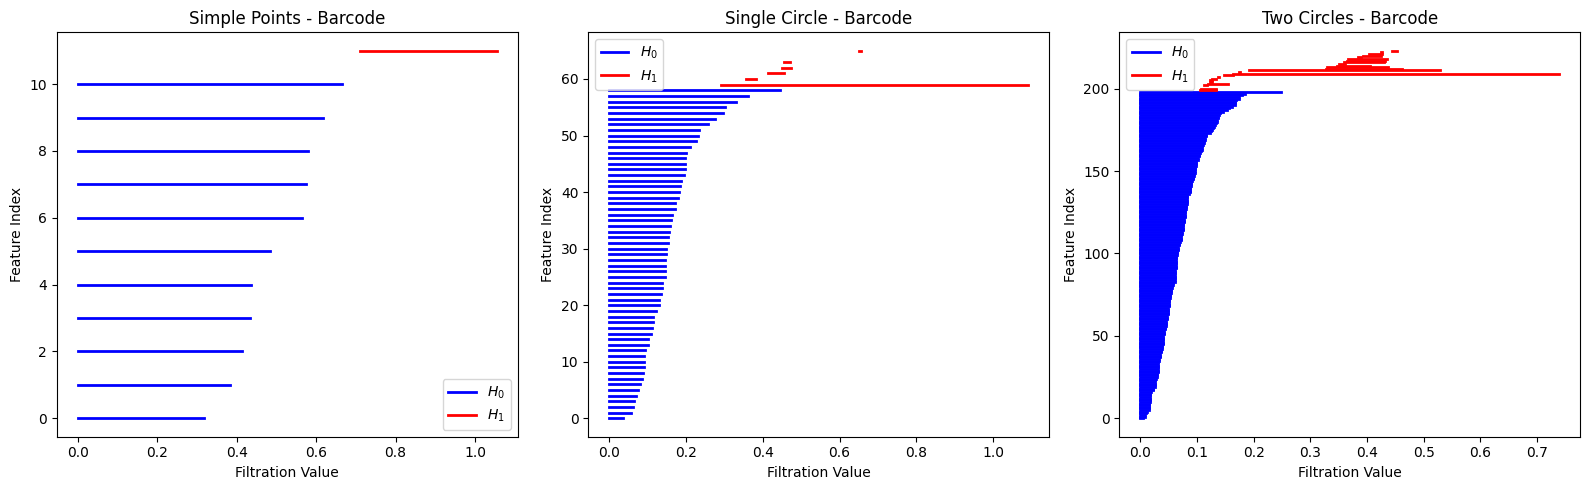


Barcodes show the lifespan of topological features:
- Blue bars: connected components (H0)
- Red bars: loops (H1)
- Longer bars indicate more persistent (significant) features


In [ ]:
def plot_barcode(dgm, title, ax):
    """Plot persistence barcode from gtda format diagram."""
    h0 = dgm[(dgm[:, 2] == 0) & (dgm[:, 0] != dgm[:, 1])]
    h1 = dgm[(dgm[:, 2] == 1) & (dgm[:, 0] != dgm[:, 1])]

    bars = []
    colors = []

    # Add H0 bars
    for birth, death, _ in h0:
        bars.append((birth, death))
        colors.append('blue')

    # Add H1 bars
    for birth, death, _ in h1:
        bars.append((birth, death))
        colors.append('red')

    # Sort by birth time
    sorted_indices = sorted(range(len(bars)), key=lambda i: bars[i][0])

    for i, idx in enumerate(sorted_indices):
        birth, death = bars[idx]
        color = colors[idx]
        ax.plot([birth, death], [i, i], color=color, linewidth=2)

    ax.set_xlabel('Filtration Value')
    ax.set_ylabel('Feature Index')
    ax.set_title(title)

    # Create legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='blue', linewidth=2, label='$H_0$'),
                       Line2D([0], [0], color='red', linewidth=2, label='$H_1$')]
    ax.legend(handles=legend_elements)

# Plot barcodes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_barcode(dgm_simple_gtda, 'Simple Points - Barcode', axes[0])
plot_barcode(dgm_circle_gtda, 'Single Circle - Barcode', axes[1])
plot_barcode(dgm_two_gtda, 'Two Circles - Barcode', axes[2])

plt.tight_layout()
plt.show()

print("\nBarcodes show the lifespan of topological features:")
print("- Blue bars: connected components (H0)")
print("- Red bars: loops (H1)")
print("- Longer bars indicate more persistent (significant) features")

## 6.2 Persistence Diagram

The **p-persistence diagram** is a 2D plot where:
- **x-axis:** birth coordinate
- **y-axis:** death coordinate

For every p-homology class there is a point $(b, d)$ representing its birth and death time.

$$PD_k(X) = \{(b_\sigma, d_\sigma) \mid \sigma \in H_k(K_i), b_\sigma \leq i \leq d_\sigma\} \cup \Delta$$

where $\Delta$ is the diagonal (points $(t, t)$).

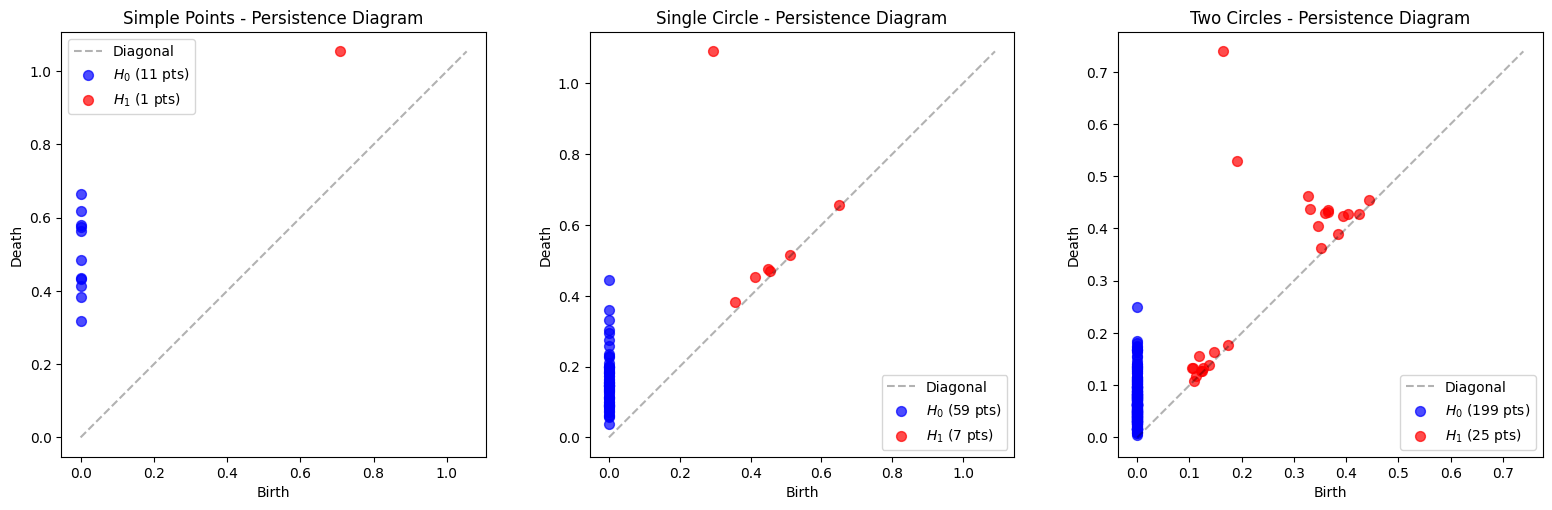

Simple points diagram shape: (12, 3)
Circle diagram shape: (66, 3)
Two circles diagram shape: (224, 3)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets_info = [
    (dgm_simple_gtda, 'Simple Points'),
    (dgm_circle_gtda, 'Single Circle'),
    (dgm_two_gtda, 'Two Circles')
]

for ax, (dgm, title) in zip(axes, datasets_info):
    # Separate by dimension
    h0 = dgm[(dgm[:, 2] == 0) & (dgm[:, 0] != dgm[:, 1])][:, :2]
    h1 = dgm[(dgm[:, 2] == 1) & (dgm[:, 0] != dgm[:, 1])][:, :2]

    max_val = max(dgm[:, 1].max(), 0.5)

    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Diagonal')
    ax.scatter(h0[:, 0], h0[:, 1], c='blue', s=50, label=f'$H_0$ ({len(h0)} pts)', alpha=0.7)
    ax.scatter(h1[:, 0], h1[:, 1], c='red', s=50, label=f'$H_1$ ({len(h1)} pts)', alpha=0.7)

    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(f'{title} - Persistence Diagram')
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Simple points diagram shape: {dgm_simple_gtda.shape}")
print(f"Circle diagram shape: {dgm_circle_gtda.shape}")
print(f"Two circles diagram shape: {dgm_two_gtda.shape}")

###  How to Interpret?

1. **High persistence** (far from diagonal) implies existence of robust features
2. **Low persistence** (near diagonal) usually represents noise
3. The summary description is always 2-dimensional
4. $\beta_0$: number of connected components (clusters?)
5. $\beta_1$: number of cycles (periodic features?)
6. $\beta_2$: number of hollow spaces

### Interpreting the Results

**Single Circle:**
- One prominent $H_1$ feature (the loop) with high persistence
- Many $H_0$ features near the diagonal (noise from sampling)

**Two Concentric Circles:**
- Two prominent $H_1$ features (both loops) with high persistence
- The inner and outer circles each contribute one loop

## 6.4 Properties of Persistence Diagrams

1. **Stable** with respect to perturbation in the data
2. **Sensitive** to "small/big" holes
3. Possible to track holes, record size/scale of the feature
4. **Not sensitive** to outliers
5. Distinguishes between significant and insignificant features

### The Stability Theorem

Let $X_1, X_2$ be two PCDs and denote by $D_p(X)$ the persistence diagram corresponding to p-persistence homology. Then:

$$d_B(D_p(X_1), D_p(X_2)) \leq d_H(X_1, X_2)$$

where $d_H(\cdot, \cdot)$ is the Hausdorff distance between the sets.

**Intuitive meaning:** The persistent homology doesn't change much under mild perturbation of the data

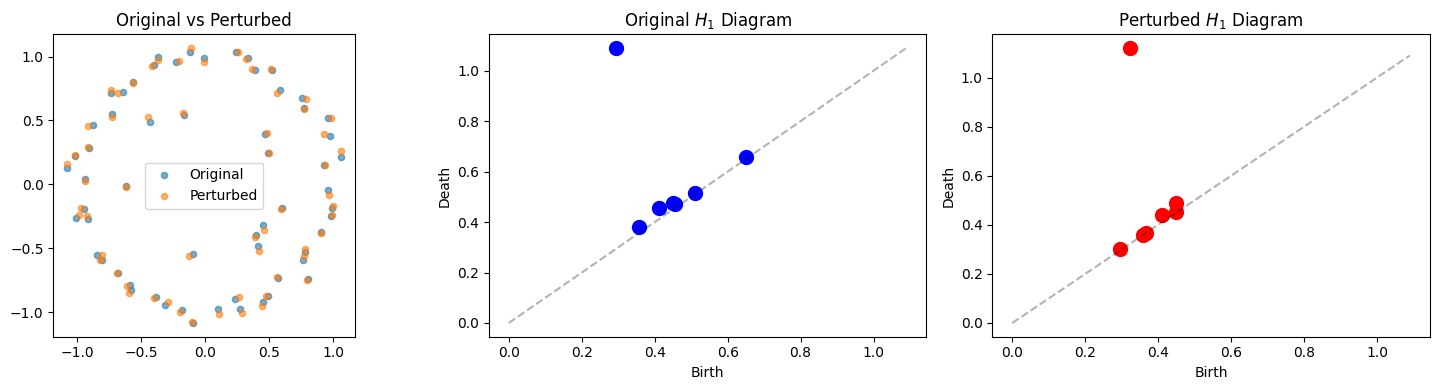

Notice: The diagrams are very similar despite the perturbation


In [ ]:
# Demonstrate stability: perturb the data and compare diagrams

# Original circle
original = circle_data.copy()

# Perturbed circle (add small noise)
np.random.seed(42)
perturbed = circle_data + np.random.normal(0, 0.02, circle_data.shape)

# Compute diagrams using ripser_parallel (consistent with rest of notebook)
dgm_orig_raw = ripser_parallel(original)
dgm_orig = _postprocess_diagrams([dgm_orig_raw["dgms"]], "ripser", (0, 1), np.inf, True)[0]

dgm_pert_raw = ripser_parallel(perturbed)
dgm_pert = _postprocess_diagrams([dgm_pert_raw["dgms"]], "ripser", (0, 1), np.inf, True)[0]

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(original[:, 0], original[:, 1], s=20, alpha=0.6, label='Original')
axes[0].scatter(perturbed[:, 0], perturbed[:, 1], s=20, alpha=0.6, label='Perturbed')
axes[0].set_title('Original vs Perturbed')
axes[0].set_aspect('equal')
axes[0].legend()

# Original diagram - H1 only
h1_orig = dgm_orig[(dgm_orig[:, 2] == 1) & (dgm_orig[:, 0] != dgm_orig[:, 1])][:, :2]
max_val = dgm_orig[:, 1].max()
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
axes[1].scatter(h1_orig[:, 0], h1_orig[:, 1], c='blue', s=100)
axes[1].set_title('Original $H_1$ Diagram')
axes[1].set_xlabel('Birth')
axes[1].set_ylabel('Death')

# Perturbed diagram - H1 only
h1_pert = dgm_pert[(dgm_pert[:, 2] == 1) & (dgm_pert[:, 0] != dgm_pert[:, 1])][:, :2]
axes[2].plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
axes[2].scatter(h1_pert[:, 0], h1_pert[:, 1], c='red', s=100)
axes[2].set_title('Perturbed $H_1$ Diagram')
axes[2].set_xlabel('Birth')
axes[2].set_ylabel('Death')

plt.tight_layout()
plt.show()

print("Notice: The diagrams are very similar despite the perturbation")

---
# 7. Bottleneck Distance

## Definition

For two persistence diagrams $X, Y$, the **bottleneck distance** ($\infty$-Wasserstein metric) is defined as:

$$d_B(X, Y) := \inf_\gamma \sup_{x \in X} \|x - \gamma(x)\|_\infty$$

where $\gamma$ runs over all matchings (bijections) from $X$ to $Y$.

**In words:** Find the best matching between points in the two diagrams. The bottleneck distance is the maximum distance between matched points in the optimal matching.

### Properties:
1. The space of PDs with $d_B$ is a metric space
2. Proves stability of PH operation

In [ ]:
# Unified helper function to extract diagrams by dimension
def extract_h(dgm_gtda, dim=1):
    """Extract diagram for specific dimension from gtda format (2D array)."""
    mask = (dgm_gtda[:, 2] == dim) & (dgm_gtda[:, 0] != dgm_gtda[:, 1])
    return dgm_gtda[mask][:, :2]

# Get H1 diagrams from stability comparison
h1_original = extract_h(dgm_orig, dim=1)
h1_perturbed = extract_h(dgm_pert, dim=1)

In [ ]:
# Compute bottleneck distance
bottleneck_dist = gudhi.bottleneck_distance(h1_original, h1_perturbed)

print(f"Bottleneck distance between original and perturbed $H_1$ diagrams: {bottleneck_dist:.6f}")
print(f"\nThis small distance confirms the stability of persistent homology.")

Bottleneck distance between original and perturbed $H_1$ diagrams: 0.030946

This small distance confirms the stability of persistent homology.


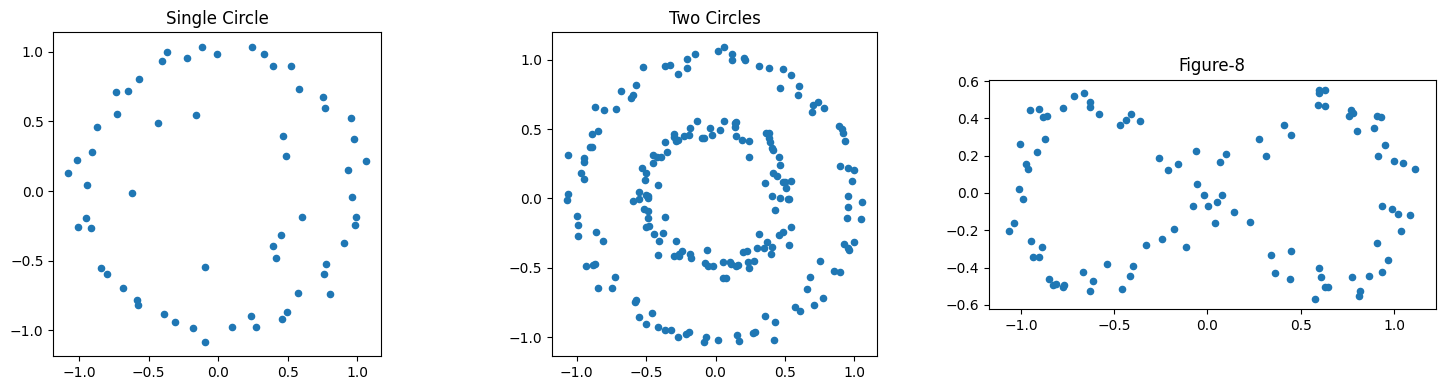

In [ ]:
# Compare different shapes using bottleneck distance
# Using ripser_parallel for all datasets

# Create a figure-8 shape (two loops)
t = np.linspace(0, 2*np.pi, 100)
np.random.seed(123)
figure_8 = np.column_stack([
    np.sin(t),
    np.sin(t) * np.cos(t)
]) + np.random.normal(0, 0.05, (100, 2))

# Compute persistence diagram for figure-8 using ripser_parallel
dgm_fig8 = ripser_parallel(figure_8)
dgm_fig8_gtda = _postprocess_diagrams([dgm_fig8["dgms"]], "ripser", (0, 1), np.inf, True)[0]

# Extract H1 diagrams using unified extract_h function
h1_circle = extract_h(dgm_circle_gtda, dim=1)
h1_two_circles = extract_h(dgm_two_gtda, dim=1)
h1_figure_8 = extract_h(dgm_fig8_gtda, dim=1)

# Visualize all shapes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(circle_data[:, 0], circle_data[:, 1], s=20)
axes[0].set_title('Single Circle')
axes[0].set_aspect('equal')

axes[1].scatter(two_circles[:, 0], two_circles[:, 1], s=20)
axes[1].set_title('Two Circles')
axes[1].set_aspect('equal')

axes[2].scatter(figure_8[:, 0], figure_8[:, 1], s=20)
axes[2].set_title('Figure-8')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
# Compute pairwise bottleneck distances
print("Pairwise Bottleneck Distances ($H_1$):")
print("=" * 50)

dist_circle_two = gudhi.bottleneck_distance(h1_circle, h1_two_circles)
dist_circle_fig8 = gudhi.bottleneck_distance(h1_circle, h1_figure_8)
dist_two_fig8 = gudhi.bottleneck_distance(h1_two_circles, h1_figure_8)

print(f"Single Circle vs Two Circles: {dist_circle_two:.4f}")
print(f"Single Circle vs Figure-8:    {dist_circle_fig8:.4f}")
print(f"Two Circles vs Figure-8:      {dist_two_fig8:.4f}")

print("\nInterpretation:")
print("- Single circle has 1 loop, two circles has 2 loops, figure-8 has 2 loops")
print("- Two circles and figure-8 should be more similar to each other")
print("- Both should be more different from the single circle")

Pairwise Bottleneck Distances ($H_1$):
Single Circle vs Two Circles: 0.3508
Single Circle vs Figure-8:    0.3897
Two Circles vs Figure-8:      0.0979

Interpretation:
- Single circle has 1 loop, two circles has 2 loops, figure-8 has 2 loops
- Two circles and figure-8 should be more similar to each other
- Both should be more different from the single circle


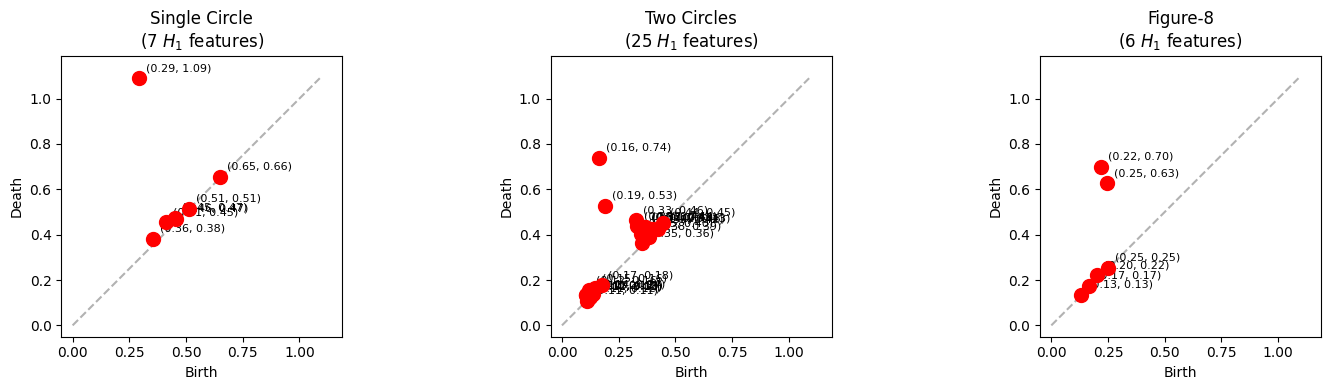

In [ ]:
# Visualize the persistence diagrams side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

diagrams = [
    (h1_circle, 'Single Circle'),
    (h1_two_circles, 'Two Circles'),
    (h1_figure_8, 'Figure-8')
]

# Find global max for consistent scaling
all_points = np.vstack([d[0] for d in diagrams if len(d[0]) > 0])
max_val = all_points.max() if len(all_points) > 0 else 1

for ax, (dgm, title) in zip(axes, diagrams):
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Diagonal')
    if len(dgm) > 0:
        ax.scatter(dgm[:, 0], dgm[:, 1], c='red', s=100, zorder=5)
        for i, (b, d) in enumerate(dgm):
            ax.annotate(f'({b:.2f}, {d:.2f})', (b, d),
                       textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(f'{title}\n({len(dgm)} $H_1$ features)')
    ax.set_xlim(-0.05, max_val + 0.1)
    ax.set_ylim(-0.05, max_val + 0.1)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Bottleneck vs Wasserstein Distance

- **Bottleneck distance:** Only sensitive to the most different points (maximum over matching)
- **Wasserstein distance:** Sensitive to all points (sum over matching)

The 2-Wasserstein metric can find more fine-scale differences in persistence diagrams compared to the bottleneck distance.